<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/Ex3_Hodgkin_Huxley/TNS_I_Exercise_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hodgkin-Huxley Model

The Hodgkin-Huxley model was developed to explain the action potential of the squid giant axon and it can be very useful to understand biological neurons. The present version is taken from Dayan\&Abbott, Sections 5.5, 5.6, and 5.11.

## State variables and parameters
The HH-model uses a single-compartment model with a leak (passive) conductance and, in addition, two further voltage-dependent (active) conductances ($Na^+$ and $K^+$). The dynamic equation of the membrane potential therefore takes into account three membrane currents and an electrode current:

\\
$$
c_m \, \frac{dV}{dt} = \, -i_L - i_{Na} - i_K \, + \, i_e, \qquad\qquad i_L = \bar g_L(V-E_L)
$$

The membrane capacity, maximal conductances, and associated reversal potentials are:

\\
\begin{align*}\begin{matrix}
&c_m = 10 \, nF/mm^2\\
\bar g_L = 3\,\mu S/mm^2 & \bar g_{Na} = 1200\,\mu S/mm^2&\bar g_K = 360\,\mu S/mm^2\\
E_L = -54.402\,mV & E_{Na} = 50\,mV & E_K = -77\,mV\\
\end{matrix}\end{align*}

\\
The sodium and potassium currents additionally depend on "activation variables" $n(V,t)$, $m(V,t)$, and $h(V,t)$

\\
$$
i_{Na} = \bar g_{Na} \, m^3\,h \, (V-E_{Na})
\qquad\qquad
i_K = \bar g_{K} \, n^4 \, (V-E_K)
$$

\\
which describe the voltage-dependence of the collective opening and closing of channels.  The activation variables are goveassociated dynamic equations are

\\
$$
\frac{dn}{dt} = \frac{1}{\tau_n}\left[n_\infty-n\right], \qquad\qquad \frac{dm}{dt} = \frac{1}{\tau_m}\left[m_\infty-m\right],  \qquad\qquad \frac{dh}{dt} = \frac{1}{\tau_h}\left[h_\infty-h\right]
$$

\\
where $\tau_{n}(V)$, $\tau_{m}(V)$, $\tau_{h}(V)$ and $n_\infty(V)$, $n_\infty(V)$, $h_\infty(V)$ are six functions of voltage $V$ provided for you, and you should call **HH_equi_tau_n**,  **HH_equi_tau_m**, and **HH_equi_tau_h**.

## Iterative Integration

Rearranging the dynamic equation of the membrane potential, we obtain:

\\

$$\frac{dV}{dt}=\frac{1}{\tau_\mathit{eff}}\left[V_\infty^\mathit{eff}-V\right]$$


\\
$$
\tau_\mathit{eff}(t) = \displaystyle\frac{c_m}{\bar g_L+\bar g_{Na}m^3h + \bar g_{K}n^4} \qquad\qquad V_\infty^\mathit{eff}(t) = \displaystyle\frac{ \bar g_LE_L+ \bar g_{Na}m^3hE_{Na} + \bar g_{K}n^4E_K + i_e}{\bar g_L+\bar g_{Na}m^3h + \bar g_{K}n^4}
$$


\\
where $\tau_\mathit{eff}$ and $V_\infty^\mathit{eff}$ are the time-varying time-constant and equilibrium potential.


Given the state variables and input current at time $t$

\\
$$
V(t), n(t), m(t), h(t), i_e(t)
$$
as well as the time-constants and equilibrium values at time $t$

\\
$$
\tau_\mathit{eff}(t), \tau_n(t), \tau_m(h), \tau_h(t), \qquad  V_\infty^\mathit{eff}(t), n_\infty(t), m_\infty(t), h_\infty(t)
$$


our task is to compute the state variables a time $t+\Delta t$

\\
$$
V(t+\Delta t), n(t+\Delta t), m(t+\Delta t), h(t+\Delta t)
$$

\\
For a sufficiently small $\Delta t$, state variables and input current can be assumed to remain constant over $\Delta t$, permitting us to use the analytical solution of the relaxation equations:

\\
$$
V(t+\Delta t) = V_\infty^\mathit{eff}(t)+\left[V(t)-V_\infty^\mathit{eff}(t)\right]\exp\left(-\frac{\Delta t}{\tau_\mathit{eff}(t)}\right)
$$

$$
n(t+\Delta t) = n_\infty(V)+\left[n(t)-n_\infty(V)\right]\exp\left(-\frac{\Delta t}{\tau_n(V)}\right)
$$

$$
m(t+\Delta t) = m_\infty(V)+\left[m(t)-m_\infty(V)\right]\exp\left(-\frac{\Delta t}{\tau_m(V)}\right)
$$
$$
h(t+\Delta t) = h_\infty(V)+\left[h(t)-h_\infty(V)\right]\exp\left(-\frac{\Delta t}{\tau_h(V)}\right)
$$


## Assignments

1. Iteratively simulate the state variables -- $V(t)$, $n(t)$, $m(t)$, $h(t)$ over a period of $40\,ms$ in steps of $\Delta t=0.1\,ms$ for different input currents (as specified below).

\\
2. First simulate with a zero input current $i_e(t) = 0 \, nA/mm^2$ and observe the resting values approached by each state variable.   For this simulation only, choose the initial conditions:

$$
V_0 = -70 \, mV, \qquad n_0 = 0.3, \qquad m_0 = h_0 = 0
$$

Note the steady-state values (resting values) towards the end of the simulation:

$$
V_\mathit{ss} \qquad n_\mathit{ss}, \qquad m_\mathit{ss}, \qquad h_\mathit{ss}
$$

\\
3. Plot the time evolution of the membrane voltage and, separately, plot the time evolution of the gating variables.

\\
4. Simulate with an input current $i_e(t) = 100 \, nA/mm^2$ to obtain action potentials.  For this simulation, choses the previously determined resting values as initial conditions:

$$
V_0=V_\mathit{ss} \qquad n_0=n_\mathit{ss}, \qquad m_0=m_\mathit{ss}, \qquad h_0=h_\mathit{ss}
$$

Your simulation should now show action potentials.

\\
5.  Repeat the previous simulation, but with a `blocked' sodium conductance, setting $\bar g_{Na}=0$.  This simulates the action of a pharmacological agent such as tetrodotoxin.

\\
6. Repeat the simulation once again, but with a 'blocked' potassium conductance, setting $\bar g_{K}=0$, simulating the effects of tetraethylammonium (TEA).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Vss is same as Vinfinity

def HH_equi_tau_n(membrane_voltage):

    alpha, beta = HH_alpha_beta_N(np.array(membrane_voltage))

    tau = 1.0 / (alpha + beta)
    asymptote = alpha / (alpha + beta)

    return asymptote, tau


def HH_alpha_beta_N(membrane_voltage):

    va = 0.1 * (membrane_voltage + 55)
    vb = 0.0125 * (membrane_voltage + 65)

    alpha = np.zeros_like(membrane_voltage)
    beta = np.zeros_like(membrane_voltage)

    # Indices where va is non-negligible (|va| > 0.01)
    ns = np.abs(va) > 0.01

    # Indices where va is approximately 0 (|va| <= 0.01)
    ss = np.abs(va) <= 0.01

    alpha[ns] = 0.1 * va[ns] / (1 - np.exp(-va[ns]))
    alpha[ss] = 1.0  # Handling for small va values to avoid division by 0

    beta = 0.125 * np.exp(-vb)

    return alpha, beta


def HH_equi_tau_m(membrane_voltage):

    alpha, beta = HH_alpha_beta_M(np.array(membrane_voltage))

    tau = 1.0 / (alpha + beta)
    asymptote = alpha / (alpha + beta)

    return asymptote, tau


def HH_alpha_beta_M(membrane_voltage):

    va = 0.1 * (membrane_voltage + 40)
    vb = 0.0556 * (membrane_voltage + 65)

    alpha = np.zeros_like(membrane_voltage)
    beta = np.zeros_like(membrane_voltage)

    # Indices where va is non-negligible (|va| > 0.01)
    ns = np.abs(va) > 0.01
    # Indices where va is approximately 0 (|va| <= 0.01)
    ss = np.abs(va) <= 0.01

    alpha[ns] = va[ns] / (1 - np.exp(-va[ns]))
    alpha[ss] = 1.0  # Handling for small va values to avoid division by 0

    beta = 4 * np.exp(-vb)

    return alpha, beta

def HH_equi_tau_h(membrane_voltage):

    alpha, beta = HH_alpha_beta_H(np.array(membrane_voltage))

    tau = 1.0 / (alpha + beta)
    asymptote = alpha / (alpha + beta)

    return asymptote, tau


def HH_alpha_beta_H(membrane_voltage):

    va = 0.05 * (membrane_voltage + 65)  # mV
    vb = 0.1 * (membrane_voltage + 35)   # mV

    alpha = 0.07 * np.exp(-va)
    beta = 1.0 / (1 + np.exp(-vb))

    return alpha, beta



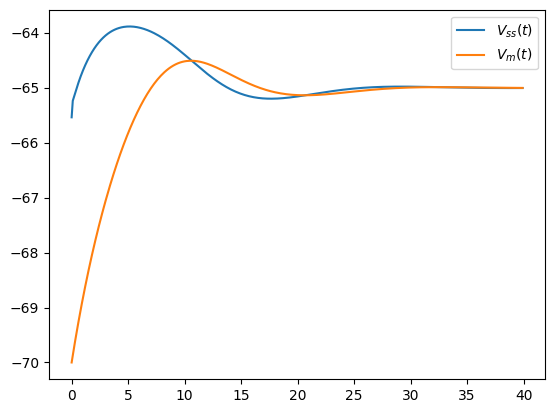

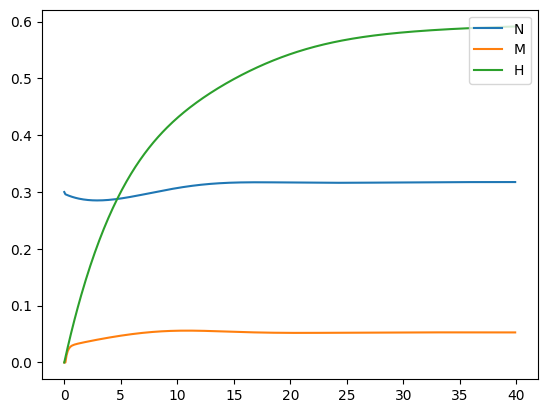

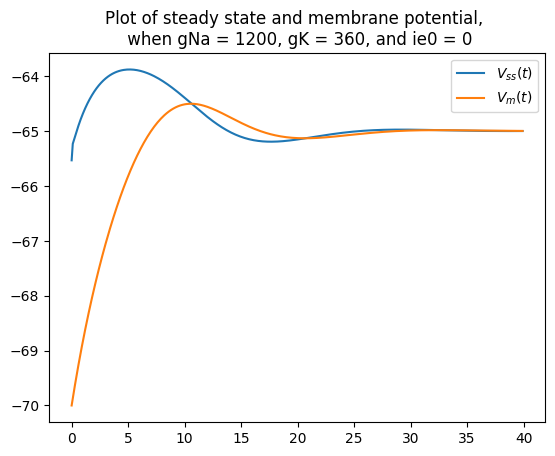

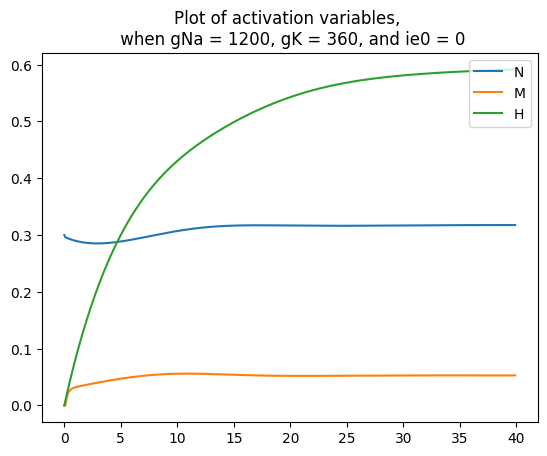

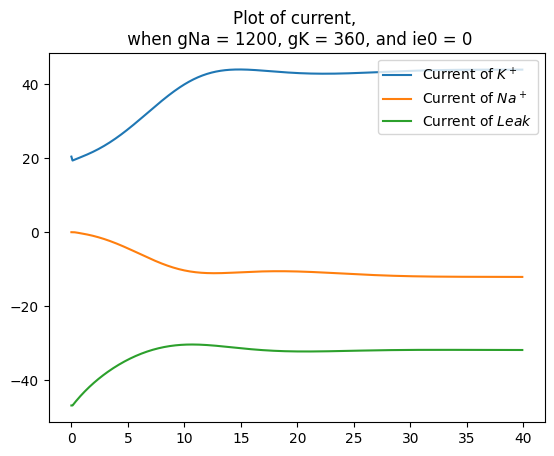

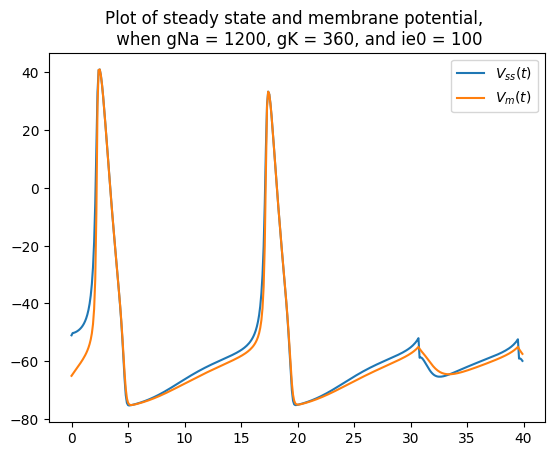

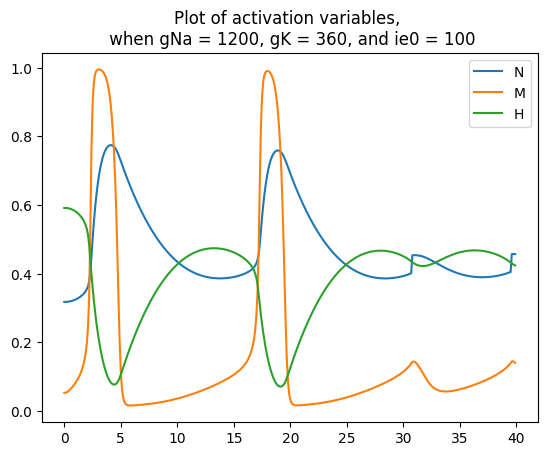

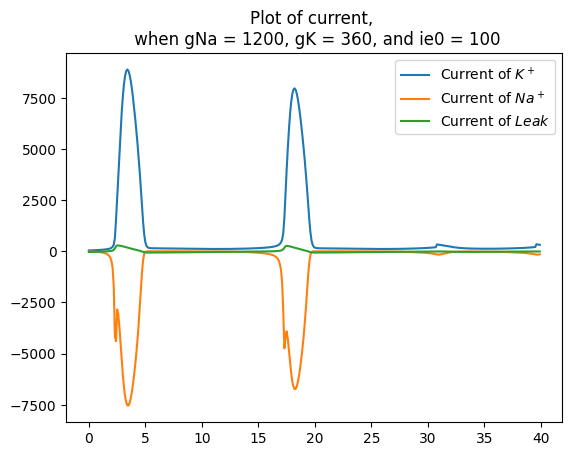

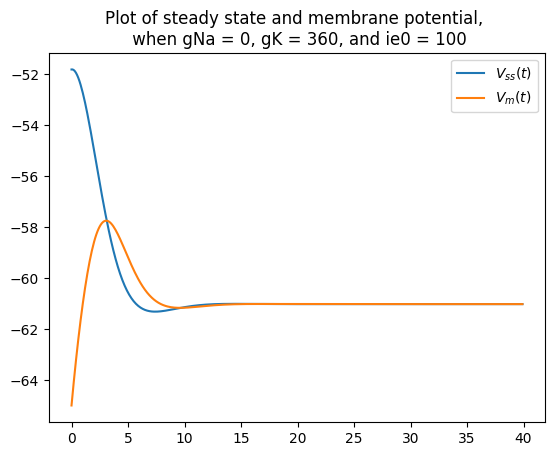

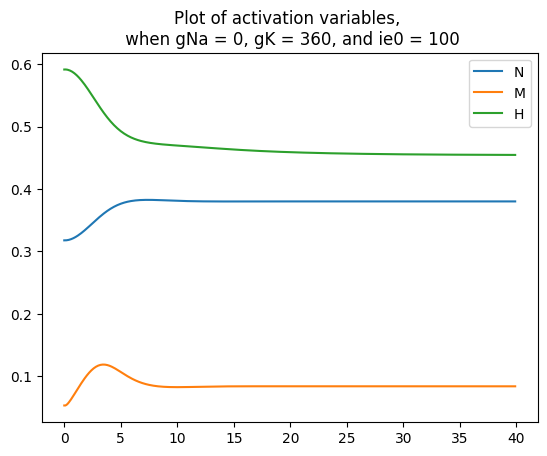

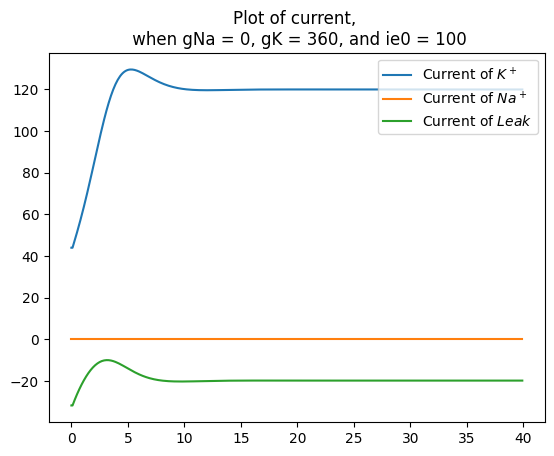

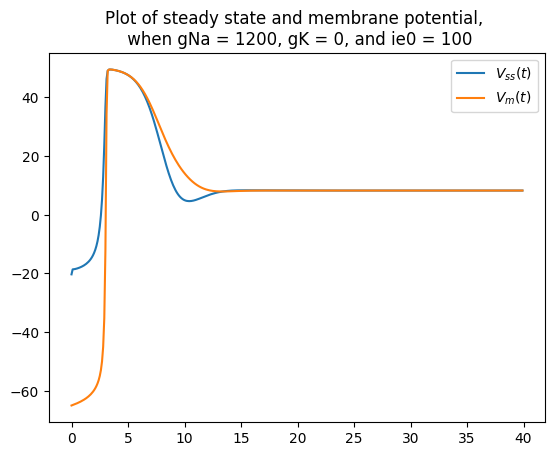

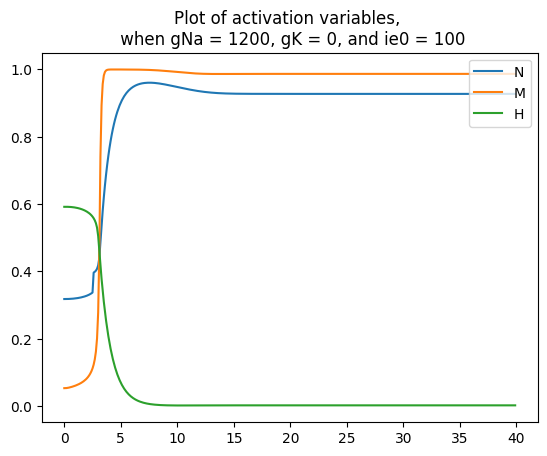

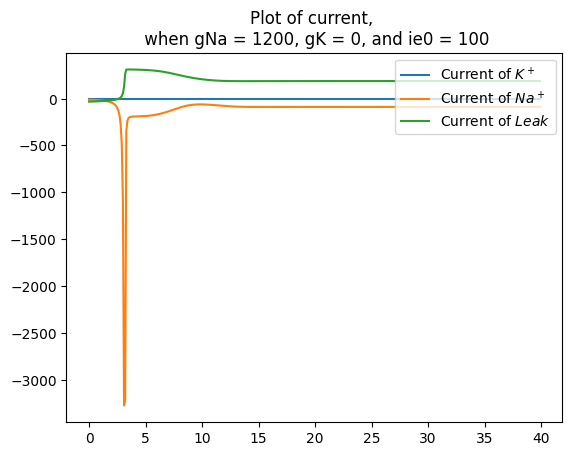

In [ ]:
#%% assignment 1.
# first defining constants and variables given

c_m = 10        # nF/mm2
g_L = 3         # uS/mm2
g_Na = 1200     # uS/mm2
g_K = 360       # us/mm2
E_L = -54.402   # mV
E_Na = 50       # mV
E_K = -77       # mV

timeVector = []
deltaT = 0.1    # mS
t = 0
tEnd = 40
while t <= tEnd:
    timeVector.append(t)
    t += deltaT

# generate values for t(0)
V_0 = -70   # mV
n_0 = 0.3
m_0 = 0
h_0 = 0
i_e_0 = 0   # nA/mm2

# can use the backslash '\' to split code across multiple lines
V_ss_0 = ((g_L * E_L) + (g_Na * m_0**3 * h_0 * E_Na) + (g_K * n_0**4 * E_K) + i_e_0) /\
    (g_L + (g_Na * m_0**3 * h_0) + (g_K * n_0**4))

tau_ss_0 = c_m / (g_L + (g_Na * m_0**3 * h_0) + (g_K * n_0**4))

i_L_0 = g_L * (V_0 - E_L)
i_K_0 = g_K * n_0**4 * (V_0 - E_K)
i_Na_0 = g_Na * (m_0**3 * h_0) * (V_0 - E_Na)

# create vectors to store membrane potential and steady state membrane potential
V_m_t = [V_0]
V_ss_t = [V_ss_0]
tau_ss_t = [tau_ss_0]
# activation variables
n_t = [n_0]
m_t = [m_0]
h_t = [h_0]
# currents
i_L_t = [i_L_0]
i_K_t = [i_K_0]
i_Na_t = [i_Na_0]
for timepoint in range(len(timeVector) - 1):
    n_ss, tau_n = HH_equi_tau_n(V_m_t[timepoint])
    m_ss, tau_m = HH_equi_tau_m(V_m_t[timepoint])
    h_ss, tau_h = HH_equi_tau_h(V_m_t[timepoint])
    n_t.append(n_ss + (n_t[timepoint] - n_ss) * np.exp(-(deltaT/tau_n)))
    m_t.append(m_ss + (m_t[timepoint] - m_ss) * np.exp(-(deltaT/tau_m)))
    h_t.append(h_ss + (h_t[timepoint] - h_ss) * np.exp(-(deltaT/tau_h)))
    i_L_t.append(g_L * (V_m_t[timepoint] - E_L))
    i_K_t.append(g_K * (n_t[timepoint + 1] **4) * (V_m_t[timepoint] - E_K))
    i_Na_t.append(g_Na * (m_t[timepoint + 1] **3 * h_t[timepoint + 1] ) * (V_m_t[timepoint] - E_Na))
    V_ss_t.append(((g_L * E_L) + (g_Na * m_t[timepoint+1]**3 * h_t[timepoint+1] * E_Na) + (g_K * n_t[timepoint+1]**4 * E_K) + i_e_0) /\
        (g_L + (g_Na * m_t[timepoint+1]**3 * h_t[timepoint+1]) + (g_K * n_t[timepoint+1]**4)))
    tau_ss_t.append(c_m / (g_L * (g_Na * m_t[timepoint + 1] **3 * h_t[timepoint + 1] ) + (g_K * n_t[timepoint + 1] **4)))
    V_m_t.append((V_ss_t[timepoint + 1] + (V_m_t[timepoint] - V_ss_t[timepoint + 1]) * np.exp (-(deltaT / tau_ss_t[timepoint + 1]))))
plt.close('all')
plt.figure()
plt.plot(timeVector, V_ss_t, label='$V_{ss} (t)$')
plt.plot(timeVector, V_m_t, label='$V_m (t)$')
plt.legend(loc='upper right')
plt.figure()
plt.plot(timeVector, n_t, label='N')
plt.plot(timeVector, m_t, label='M')
plt.plot(timeVector, h_t, label='H')
plt.legend(loc='upper right')

#%%
def runHH(n=0.3, m=0, h=0, V_0=-70, i_e_0=0, g_Na=1200, g_K=360, g_L=3, tEnd=40):
    # set up constants
    c_m = 10        # nF/mm2
    E_L = -54.402   # mV
    E_Na = 50       # mV
    E_K = -77
    # create time vector
    timeVector = []
    deltaT = 0.1    # mS
    t = 0
    while t <= tEnd:
        timeVector.append(t)
        t += deltaT
    # create vectors to store membrane potential and steady state membrane potential
    V_ss_0 = ((g_L * E_L) + (g_Na * m**3 * h_0 * E_Na) + (g_K * n**4 * E_K) + i_e_0) /\
        (g_L + (g_Na * m**3 * h) + (g_K * n**4))

    tau_ss_0 = c_m / (g_L + (g_Na * m**3 * h) + (g_K * n**4))
    V_m_t = [V_0]
    V_ss_t = [V_ss_0]
    tau_ss_t = [tau_ss_0]
    i_L_0 = g_L * (V_0 - E_L)
    i_K_0 = g_K * n**4 * (V_0 - E_K)
    i_Na_0 = g_Na * (m**3 * h) * (V_0 - E_Na)

    # vectors activation variables
    n_t = [n]
    m_t = [m]
    h_t = [h]
    # vectors for currents
    i_L_t = [i_L_0]
    i_K_t = [i_K_0]
    i_Na_t = [i_Na_0]
    for timepoint in range(len(timeVector) - 1):
        # calculate steady states and tau for activation variables
        n_ss, tau_n = HH_equi_tau_n(V_m_t[timepoint])
        m_ss, tau_m = HH_equi_tau_m(V_m_t[timepoint])
        h_ss, tau_h = HH_equi_tau_h(V_m_t[timepoint])
        n_t.append(n_ss + (n_t[timepoint] - n_ss) * np.exp(-(deltaT/tau_n)))
        m_t.append(m_ss + (m_t[timepoint] - m_ss) * np.exp(-(deltaT/tau_m)))
        h_t.append(h_ss + (h_t[timepoint] - h_ss) * np.exp(-(deltaT/tau_h)))
        # calculate current
        i_L_t.append(g_L * (V_m_t[timepoint] - E_L))
        # start of [timepoint + 1]
        i_K_t.append(g_K * (n_t[timepoint + 1] **4) * (V_m_t[timepoint] - E_K))
        i_Na_t.append(g_Na * (m_t[timepoint + 1] **3 * h_t[timepoint + 1] ) * (V_m_t[timepoint] - E_Na))
        # calculate V_ss(t + dt) and tau_ss(t + dt)
        V_ss_t.append(((g_L * E_L) + (g_Na * m_t[timepoint+1]**3 * h_t[timepoint+1] * E_Na) + (g_K * n_t[timepoint+1]**4 * E_K) + i_e_0) /\
            (g_L + (g_Na * m_t[timepoint+1]**3 * h_t[timepoint+1]) + (g_K * n_t[timepoint+1]**4)))
        tau_ss_t.append(c_m / (g_L * (g_Na * m_t[timepoint + 1] **3 * h_t[timepoint + 1] ) + (g_K * n_t[timepoint + 1] **4)))
        # calculate V_m(t)
        V_m_t.append((V_ss_t[timepoint + 1] + (V_m_t[timepoint] - V_ss_t[timepoint + 1]) * np.exp(-(deltaT / tau_ss_t[timepoint + 1]))))
    # plot steady state potential and membrane potential
    plt.figure()
    plt.plot(timeVector, V_ss_t, label='$V_{ss} (t)$')
    plt.plot(timeVector, V_m_t, label='$V_m (t)$')
    plt.legend(loc='upper right')
    plt.title(f'Plot of steady state and membrane potential, \n when gNa = {g_Na}, gK = {g_K}, and ie0 = {i_e_0}')
    plt.show()
    # plot the activation variables
    plt.figure()
    plt.plot(timeVector, n_t, label='N')
    plt.plot(timeVector, m_t, label='M')
    plt.plot(timeVector, h_t, label='H')
    plt.legend(loc='upper right')
    plt.title(f'Plot of activation variables, \n when gNa = {g_Na}, gK = {g_K}, and ie0 = {i_e_0}')
    plt.show()
    # plot the activation variables
    plt.figure()
    plt.plot(timeVector, i_K_t, label='Current of $K^+$')
    plt.plot(timeVector, i_Na_t, label='Current of $Na^+$')
    plt.plot(timeVector, i_L_t, label='Current of $Leak$')
    plt.legend(loc='upper right')
    plt.title(f'Plot of current, \n when gNa = {g_Na}, gK = {g_K}, and ie0 = {i_e_0}')
    plt.show()
    return n_t, m_t, h_t, V_m_t
# plt.close('all')
n_t, m_t, h_t, V_m_t = runHH()
#%% part 4, updating i_e_0 to -100 and using steady state values from original calculation
# plt.close('all')
n_t100, m_t100, h_t100, V_m_t100 = runHH(n=n_t[-1], m=m_t[-1], h=h_t[-1], V_0=V_m_t[-1], i_e_0=100)
#%% part 5, set Na conductance to 0
# plt.close('all')
n_t100, m_t100, h_t100, V_m_t100 = runHH(n=n_t[-1], m=m_t[-1], h=h_t[-1], V_0=V_m_t[-1], i_e_0=100, g_Na=0)
#%% part 6, set K conductance to 0
# plt.close('all')
n_t100, m_t100, h_t100, V_m_t100 = runHH(n=n_t[-1], m=m_t[-1], h=h_t[-1], V_0=V_m_t[-1], i_e_0=100, g_K=0)